# Phase 3 — CLT Demonstration and Confidence Intervals

This notebook demonstrates the **Central Limit Theorem** visually:
the standardised sum of LogNormal random variables converges to a
Normal distribution as $n$ grows. We also show how to compute
confidence intervals and choose $N$ for Monte Carlo.

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
rng = np.random.default_rng(42)

## 1. CLT Normality Emergence

We draw $n$ i.i.d. LogNormal variables, compute the standardised mean,
and repeat 10,000 times. As $n$ increases, the histogram converges
to $N(0,1)$.

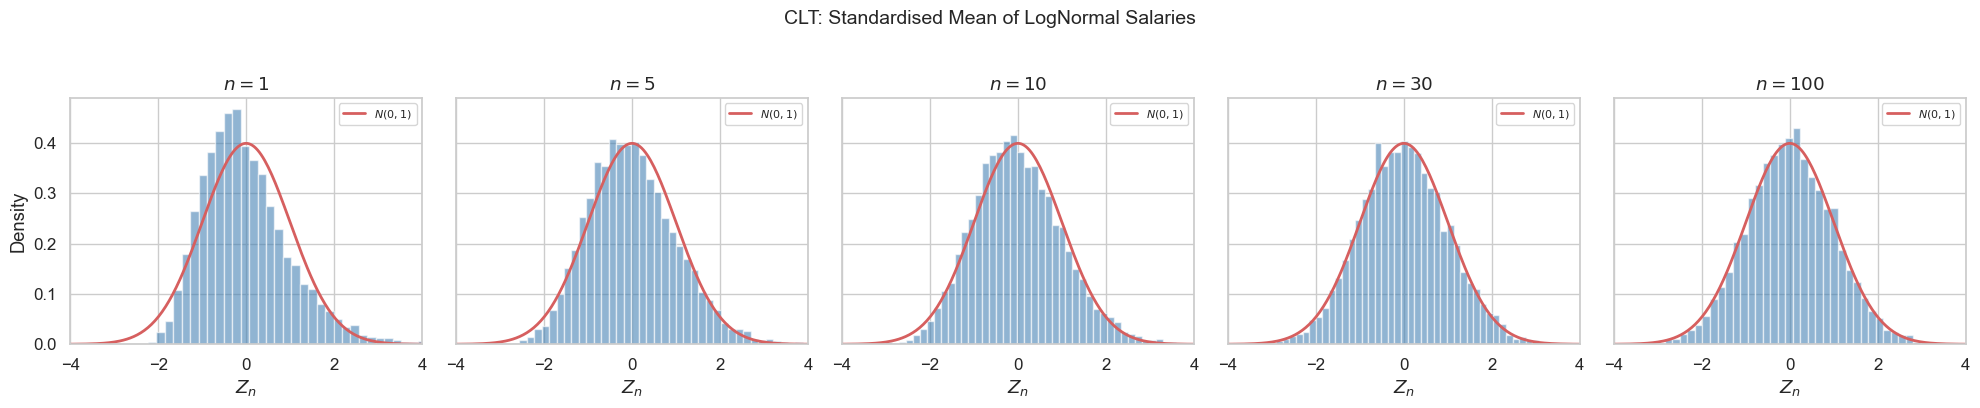

Saved: figures/clt_normality_emergence.png


In [2]:
mu_s, sigma_s = 9.2, 0.3
E_S = np.exp(mu_s + sigma_s**2 / 2)
Var_S = (np.exp(sigma_s**2) - 1) * np.exp(2 * mu_s + sigma_s**2)
SD_S = np.sqrt(Var_S)

n_values = [1, 5, 10, 30, 100]
n_repetitions = 10_000

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
x_grid = np.linspace(-4, 4, 200)
standard_normal_pdf = stats.norm.pdf(x_grid)

for ax, n in zip(axes, n_values):
    # Draw n samples, repeat n_repetitions times
    samples = rng.lognormal(mean=mu_s, sigma=sigma_s,
                            size=(n_repetitions, n))
    # Sample means
    sample_means = samples.mean(axis=1)
    # Standardise: Z = sqrt(n) * (X_bar - mu) / sigma
    z_scores = np.sqrt(n) * (sample_means - E_S) / SD_S

    ax.hist(z_scores, bins=50, density=True, alpha=0.6,
            color="steelblue", edgecolor="white")
    ax.plot(x_grid, standard_normal_pdf, "r-", lw=2, label="$N(0,1)$")
    ax.set_title(f"$n = {n}$")
    ax.set_xlim(-4, 4)
    ax.set_xlabel("$Z_n$")
    if n == 1:
        ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("CLT: Standardised Mean of LogNormal Salaries",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../figures/clt_normality_emergence.png", dpi=300,
            bbox_inches="tight")
plt.show()
print("Saved: figures/clt_normality_emergence.png")

## 2. QQ-Plots

QQ-plots compare the empirical quantiles of $Z_n$ against
theoretical $N(0,1)$ quantiles. If the CLT holds, the points
fall on the $y = x$ line.

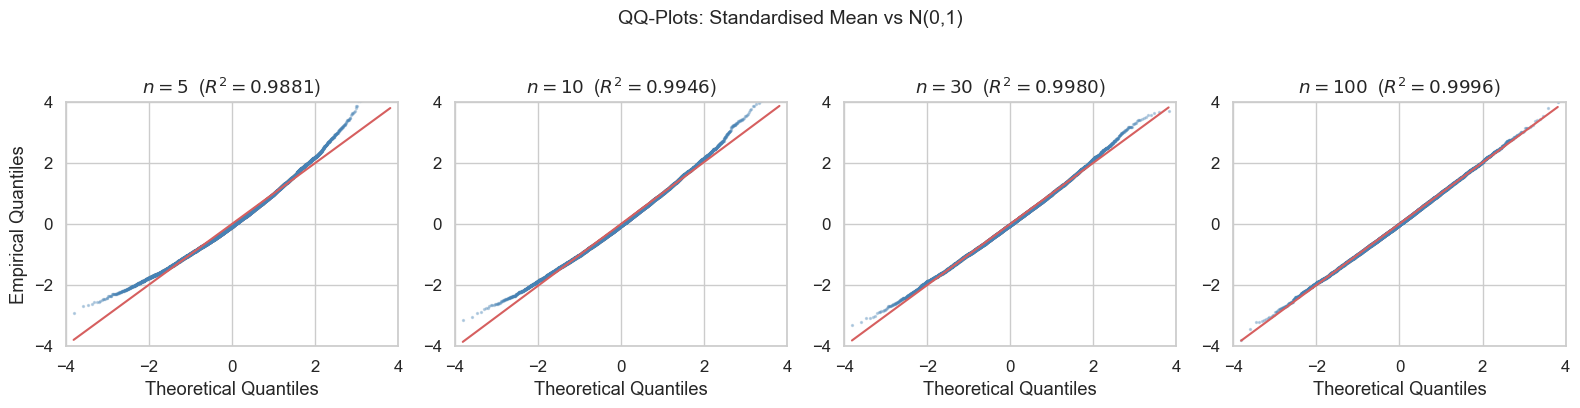

Saved: figures/clt_qq_plot.png


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

qq_n_values = [5, 10, 30, 100]

for ax, n in zip(axes, qq_n_values):
    samples = rng.lognormal(mean=mu_s, sigma=sigma_s,
                            size=(n_repetitions, n))
    sample_means = samples.mean(axis=1)
    z_scores = np.sqrt(n) * (sample_means - E_S) / SD_S

    (osm, osr), (slope, intercept, r) = stats.probplot(z_scores, dist="norm")
    ax.scatter(osm, osr, s=2, alpha=0.3, color="steelblue")
    ax.plot(osm, slope * osm + intercept, "r-", lw=1.5)
    ax.set_title(f"$n = {n}$  ($R^2 = {r**2:.4f}$)")
    ax.set_xlabel("Theoretical Quantiles")
    if n == qq_n_values[0]:
        ax.set_ylabel("Empirical Quantiles")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)

fig.suptitle("QQ-Plots: Standardised Mean vs N(0,1)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../figures/clt_qq_plot.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/clt_qq_plot.png")

## 3. CLT on the Full Budget Model

The budget cost $X_{\text{total}}$ is a sum of many random components.
We verify that the distribution of $\bar{X}_N$ (the Monte Carlo estimate)
is approximately Normal.

In [4]:
# Budget model parameters
n_employees = 50
beta = 1.80
lambda_h = 5
r_ot = 80
lambda_I = 3
mu_I, sigma_I = 10.5, 0.5


def simulate_one_year(rng: np.random.Generator) -> float:
    """Simulate one year of the budget model."""
    salaries = rng.lognormal(mean=mu_s, sigma=sigma_s, size=n_employees)
    term1 = np.sum(salaries) * beta * 12
    overtime_hours = rng.poisson(lam=lambda_h, size=(n_employees, 12))
    term2 = np.sum(overtime_hours) * r_ot
    n_incidents = rng.poisson(lam=lambda_I)
    term3 = (
        np.sum(rng.lognormal(mean=mu_I, sigma=sigma_I, size=n_incidents))
        if n_incidents > 0
        else 0.0
    )
    return term1 + term2 + term3


# Run many batches: each batch is N simulations, compute batch mean
N_per_batch = 100
n_batches = 5_000

batch_means = []
for _ in range(n_batches):
    batch_rng = np.random.default_rng()
    costs = np.array([simulate_one_year(batch_rng) for _ in range(N_per_batch)])
    batch_means.append(costs.mean())

batch_means = np.array(batch_means)

# Standardise
overall_mean = batch_means.mean()
overall_std = batch_means.std()
z_budget = (batch_means - overall_mean) / overall_std

print(f"Mean of batch means: R$ {overall_mean:,.2f}")
print(f"SD of batch means:   R$ {overall_std:,.2f}")

Mean of batch means: R$ 11,545,928.92
SD of batch means:   R$ 48,002.52


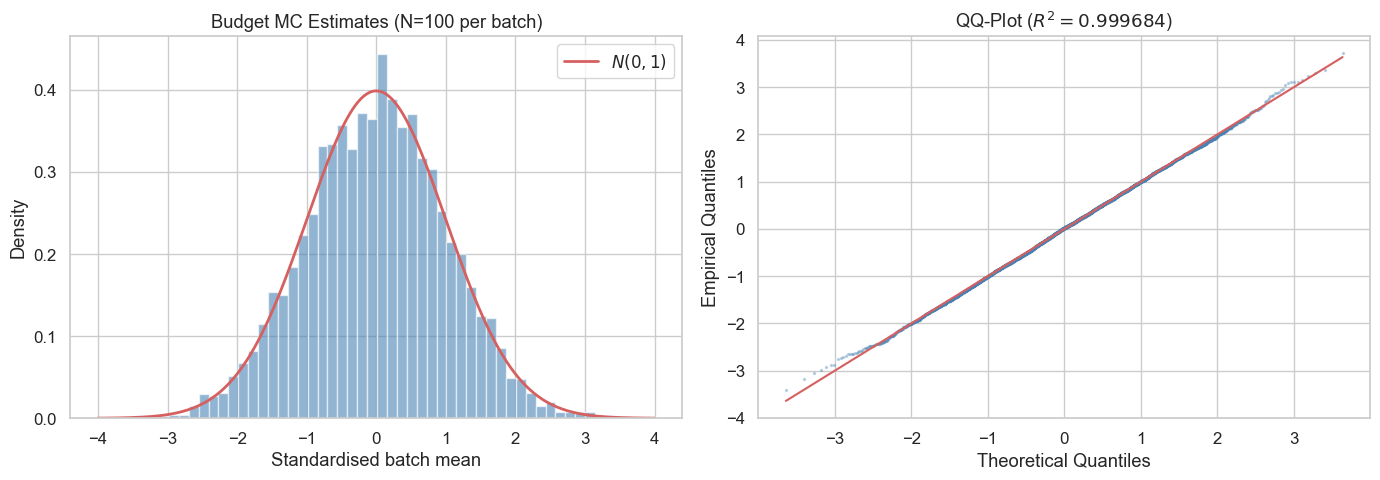

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram vs N(0,1)
x_grid = np.linspace(-4, 4, 200)
ax1.hist(z_budget, bins=50, density=True, alpha=0.6,
         color="steelblue", edgecolor="white")
ax1.plot(x_grid, stats.norm.pdf(x_grid), "r-", lw=2, label="$N(0,1)$")
ax1.set_xlabel("Standardised batch mean")
ax1.set_ylabel("Density")
ax1.set_title(f"Budget MC Estimates (N={N_per_batch} per batch)")
ax1.legend()

# QQ-plot
(osm, osr), (slope, intercept, r) = stats.probplot(z_budget, dist="norm")
ax2.scatter(osm, osr, s=2, alpha=0.3, color="steelblue")
ax2.plot(osm, slope * osm + intercept, "r-", lw=1.5)
ax2.set_xlabel("Theoretical Quantiles")
ax2.set_ylabel("Empirical Quantiles")
ax2.set_title(f"QQ-Plot ($R^2 = {r**2:.6f}$)")

plt.tight_layout()
plt.savefig("../figures/clt_budget_normality.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 4. Confidence Interval Demonstration

We run 200 independent simulations of size $N = 500$. For each,
we compute a 95% CI. The CLT predicts ~95% of CIs contain the
true mean.

In [6]:
N_sim = 500
n_experiments = 200
alpha = 0.05
z_crit = stats.norm.ppf(1 - alpha / 2)  # 1.96

# Use analytical E[X_total] as "true" mean
E_C = np.exp(mu_I + sigma_I**2 / 2)
E_total = (n_employees * beta * 12 * E_S
           + n_employees * r_ot * 12 * lambda_h
           + lambda_I * E_C)

ci_lower = np.zeros(n_experiments)
ci_upper = np.zeros(n_experiments)
x_bars = np.zeros(n_experiments)
contains_true = np.zeros(n_experiments, dtype=bool)

for i in range(n_experiments):
    exp_rng = np.random.default_rng(seed=1000 + i)
    costs = np.array([simulate_one_year(exp_rng) for _ in range(N_sim)])
    x_bar = costs.mean()
    s = costs.std(ddof=1)
    se = s / np.sqrt(N_sim)
    ci_lower[i] = x_bar - z_crit * se
    ci_upper[i] = x_bar + z_crit * se
    x_bars[i] = x_bar
    contains_true[i] = ci_lower[i] <= E_total <= ci_upper[i]

coverage = contains_true.mean()
print(f"Empirical coverage: {coverage:.1%} (expected: 95.0%)")
print(f"CIs containing true mean: {contains_true.sum()} / {n_experiments}")

Empirical coverage: 97.5% (expected: 95.0%)
CIs containing true mean: 195 / 200


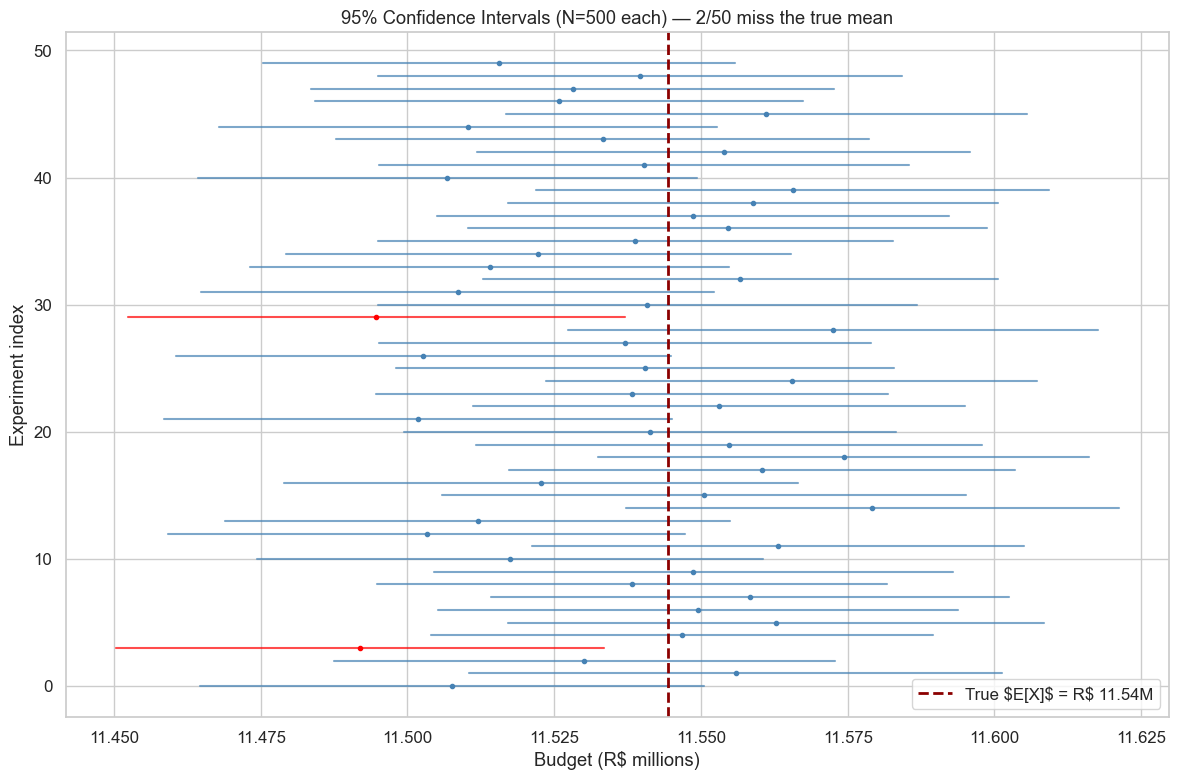

In [7]:
# Plot first 50 CIs
n_show = 50
fig, ax = plt.subplots(figsize=(12, 8))

for i in range(n_show):
    color = "steelblue" if contains_true[i] else "red"
    ax.plot([ci_lower[i] / 1e6, ci_upper[i] / 1e6], [i, i],
            color=color, lw=1.5, alpha=0.7)
    ax.plot(x_bars[i] / 1e6, i, "o", color=color, ms=3)

ax.axvline(E_total / 1e6, color="darkred", ls="--", lw=2,
           label=f"True $E[X]$ = R$ {E_total/1e6:.2f}M")

n_miss = n_show - contains_true[:n_show].sum()
ax.set_xlabel("Budget (R$ millions)")
ax.set_ylabel("Experiment index")
ax.set_title(f"95% Confidence Intervals (N={N_sim} each) — "
             f"{n_miss}/{n_show} miss the true mean")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../figures/clt_ci_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Choosing N: Precision vs Computational Cost

In [8]:
# Pilot estimate of sigma
pilot_rng = np.random.default_rng(42)
pilot_costs = np.array([simulate_one_year(pilot_rng) for _ in range(200)])
sigma_hat = pilot_costs.std(ddof=1)
print(f"Pilot sigma estimate: R$ {sigma_hat:,.2f}")

# Required N for various precisions at 95%
z_95 = 1.96
epsilons = [500_000, 200_000, 100_000, 50_000, 25_000, 10_000]

print(f"\n{'Precision (±R$)':>18}  {'Required N':>12}  {'CI Width (R$)':>14}")
print("-" * 50)
for eps in epsilons:
    N_req = int(np.ceil((z_95 * sigma_hat / eps) ** 2))
    ci_width = 2 * eps
    print(f"{eps:>18,}  {N_req:>12,}  {ci_width:>14,}")

Pilot sigma estimate: R$ 465,578.59

   Precision (±R$)    Required N   CI Width (R$)
--------------------------------------------------
           500,000             4       1,000,000
           200,000            21         400,000
           100,000            84         200,000
            50,000           334         100,000
            25,000         1,333          50,000
            10,000         8,328          20,000


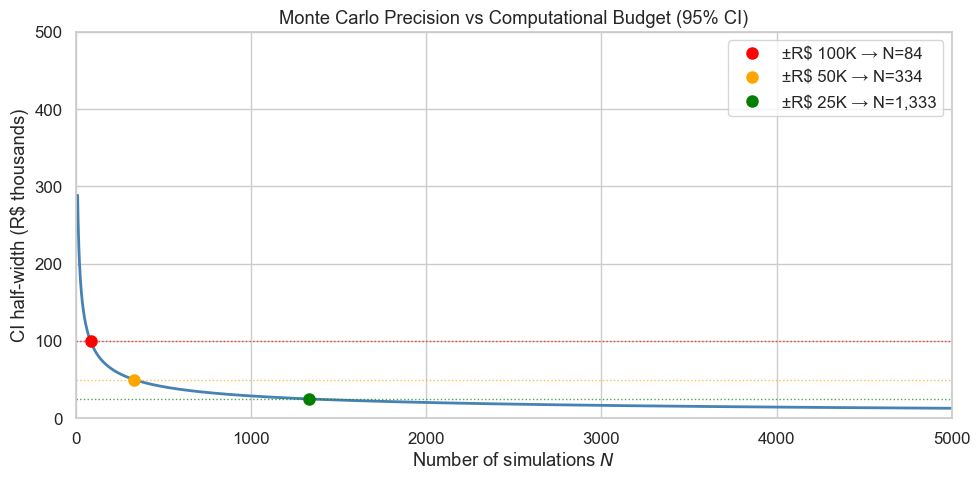

In [9]:
# Plot: CI half-width vs N
N_range = np.arange(10, 10_001)
half_widths = z_95 * sigma_hat / np.sqrt(N_range)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(N_range, half_widths / 1e3, color="steelblue", lw=2)

# Mark key thresholds
for eps, color in [(100_000, "red"), (50_000, "orange"), (25_000, "green")]:
    N_req = int(np.ceil((z_95 * sigma_hat / eps) ** 2))
    ax.axhline(eps / 1e3, color=color, ls=":", lw=1, alpha=0.7)
    ax.plot(N_req, eps / 1e3, "o", color=color, ms=8,
            label=f"±R$ {eps/1e3:.0f}K → N={N_req:,}")

ax.set_xlabel("Number of simulations $N$")
ax.set_ylabel("CI half-width (R$ thousands)")
ax.set_title("Monte Carlo Precision vs Computational Budget (95% CI)")
ax.legend()
ax.set_xlim(0, 5_000)
ax.set_ylim(0, 500)
plt.tight_layout()
plt.savefig("../figures/clt_precision_vs_n.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 6. Chebyshev vs CLT: Head-to-Head

In [10]:
epsilon = 100_000
alpha_val = 0.05

N_chebyshev = int(np.ceil(sigma_hat**2 / (alpha_val * epsilon**2)))
N_clt = int(np.ceil((z_95 * sigma_hat / epsilon) ** 2))

print("Required N for P(|X̄ - μ| ≥ R$ 100K) ≤ 0.05:")
print(f"  Chebyshev: N ≥ {N_chebyshev:,}")
print(f"  CLT:       N ≥ {N_clt:,}")
print(f"  Ratio:     {N_chebyshev / N_clt:.1f}x")

Required N for P(|X̄ - μ| ≥ R$ 100K) ≤ 0.05:
  Chebyshev: N ≥ 434
  CLT:       N ≥ 84
  Ratio:     5.2x


## Key Takeaways

1. **CLT works on LogNormal sums.** Even with $n = 10$, the histogram
   is recognisably Normal. By $n = 30$, QQ-plots are nearly linear.

2. **95% CIs achieve ~95% coverage.** Empirical coverage matches the
   theoretical prediction, validating the CLT approximation.

3. **CLT is ~5x more efficient than Chebyshev** for choosing $N$.
   The Normal approximation exploits distributional shape, not just
   mean and variance.

4. **Precision scales as $O(1/\sqrt{N})$.** Halving the CI width
   requires 4x more simulations — a fundamental trade-off.

### Next: Phase 4

With the theory complete (E/Var → LLN → CLT), Phase 4 formalises
the Monte Carlo estimator and implements the budget simulation engine.